# Retrieval Evaluation

This notebook presents the retrieval benchmark results for DebugAssistant

## Benchmark Setup

The benchmark uses 50 manually designed Java and Spring debugging queries

It compares two retrieval methods
- TF IDF
- Sentence BERT plus FAISS

The evaluation includes full stack traces truncated traces and paraphrased issue descriptions

The benchmark results shown here are generated by the evaluation script in `eval/run_retrieval_eval.py`

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


def resolve_base_dir() -> Path:
    cwd = Path.cwd()
    if (cwd / "eval").exists() and (cwd / "data").exists():
        return cwd
    if (cwd / "ml-service" / "eval").exists() and (cwd / "ml-service" / "data").exists():
        return cwd / "ml-service"
    raise FileNotFoundError("Could not find ml-service base directory with eval and data folders")


base_dir = resolve_base_dir()
eval_dir = base_dir / "eval"

results_path = eval_dir / "results_v1.json"
detailed_path = eval_dir / "detailed_results_v1.json"

with open(results_path, "r", encoding="utf-8") as f:
    results = json.load(f)

with open(detailed_path, "r", encoding="utf-8") as f:
    detailed_results = json.load(f)

detailed_df = pd.DataFrame(detailed_results)

print(f"Loaded results from {results_path}")
print(f"Loaded detailed results from {detailed_path}")
print(f"Number of queries: {len(detailed_df)}")


Loaded results from C:\Users\Daniel Samoylov\Desktop\debugassistant\ml-service\eval\results_v1.json
Loaded detailed results from C:\Users\Daniel Samoylov\Desktop\debugassistant\ml-service\eval\detailed_results_v1.json
Number of queries: 50


## Overall Results

This table shows the overall retrieval performance of both methods on the 50 query benchmark

In [2]:
summary_df = pd.DataFrame([
    {
        "method": "TF IDF",
        "hit_at_1": results["tfidf"]["hit_at_1"],
        "hit_at_3": results["tfidf"]["hit_at_3"],
        "mrr": results["tfidf"]["mrr"],
        "hit_at_1_count": results["tfidf"]["hit_at_1_count"],
        "hit_at_3_count": results["tfidf"]["hit_at_3_count"],
        "num_queries": results["tfidf"]["num_queries"],
    },
    {
        "method": "Sentence BERT + FAISS",
        "hit_at_1": results["sentence_bert_faiss"]["hit_at_1"],
        "hit_at_3": results["sentence_bert_faiss"]["hit_at_3"],
        "mrr": results["sentence_bert_faiss"]["mrr"],
        "hit_at_1_count": results["sentence_bert_faiss"]["hit_at_1_count"],
        "hit_at_3_count": results["sentence_bert_faiss"]["hit_at_3_count"],
        "num_queries": results["sentence_bert_faiss"]["num_queries"],
    },
])

summary_display = summary_df.copy()
for col in ["hit_at_1", "hit_at_3", "mrr"]:
    summary_display[col] = summary_display[col].map(lambda x: f"{x:.3f}")

summary_display


,method,hit_at_1,hit_at_3,mrr,hit_at_1_count,hit_at_3_count,num_queries
0,TF IDF,0.680,0.860,0.763,34,43,50
1,Sentence BERT + FAISS,0.880,0.980,0.927,44,49,50


## Breakdown by Query Type

This breakdown shows how both methods perform on different query styles

The main question here is whether semantic retrieval is especially useful for truncated traces and paraphrased debugging queries

In [3]:
query_type_df = detailed_df.groupby("query_type").agg(
    tfidf_hit_at_1=("tfidf_hit_at_1", "mean"),
    tfidf_hit_at_3=("tfidf_hit_at_3", "mean"),
    sbert_hit_at_1=("sbert_hit_at_1", "mean"),
    sbert_hit_at_3=("sbert_hit_at_3", "mean"),
    count=("query_id", "count"),
).reset_index()

query_type_display = query_type_df.copy()
for col in ["tfidf_hit_at_1", "tfidf_hit_at_3", "sbert_hit_at_1", "sbert_hit_at_3"]:
    query_type_display[col] = query_type_display[col].map(lambda x: f"{x:.3f}")

query_type_display


,query_type,tfidf_hit_at_1,tfidf_hit_at_3,sbert_hit_at_1,sbert_hit_at_3,count
0,full_trace,1.000,1.000,1.000,1.000,5
1,paraphrase,0.529,0.794,0.853,0.971,34
2,truncated_trace,1.000,1.000,0.909,1.000,11


## Breakdown by Difficulty

This table shows whether the performance gap changes across easy medium and hard queries

In [4]:
difficulty_df = detailed_df.groupby("difficulty").agg(
    tfidf_hit_at_1=("tfidf_hit_at_1", "mean"),
    tfidf_hit_at_3=("tfidf_hit_at_3", "mean"),
    sbert_hit_at_1=("sbert_hit_at_1", "mean"),
    sbert_hit_at_3=("sbert_hit_at_3", "mean"),
    count=("query_id", "count"),
).reset_index()

difficulty_display = difficulty_df.copy()
for col in ["tfidf_hit_at_1", "tfidf_hit_at_3", "sbert_hit_at_1", "sbert_hit_at_3"]:
    difficulty_display[col] = difficulty_display[col].map(lambda x: f"{x:.3f}")

difficulty_display


,difficulty,tfidf_hit_at_1,tfidf_hit_at_3,sbert_hit_at_1,sbert_hit_at_3,count
0,easy,0.800,1.000,1.000,1.000,10
1,hard,0.692,0.923,0.846,1.000,13
2,medium,0.630,0.778,0.852,0.963,27


## Visual Comparison

This chart compares the overall top 1 and top 3 retrieval performance of both methods

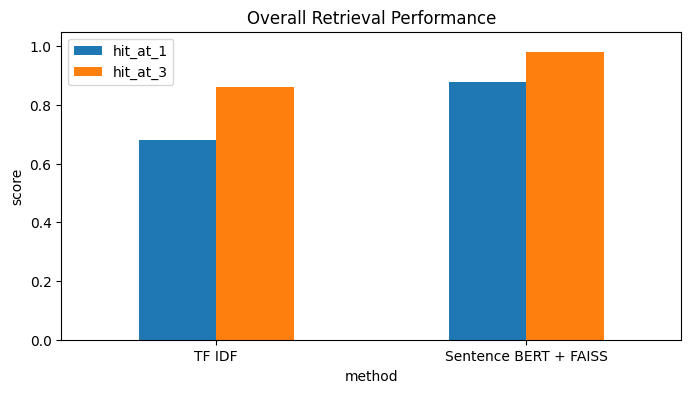

In [5]:
plot_df = summary_df.set_index("method")[["hit_at_1", "hit_at_3"]]
ax = plot_df.plot(kind="bar", figsize=(8, 4), rot=0)
ax.set_ylabel("score")
ax.set_ylim(0, 1.05)
ax.set_title("Overall Retrieval Performance")
plt.show()


## Failure Cases

These rows are the most useful for qualitative analysis

They highlight three kinds of cases
- TF IDF misses at top 1
- TF IDF complete misses outside top 3
- Sentence BERT top 1 confusions

This section helps explain where sparse retrieval degrades and where semantic retrieval still struggles with closely related exception families

In [6]:
failure_df = detailed_df[
    (~detailed_df["tfidf_hit_at_1"]) |
    (~detailed_df["tfidf_hit_at_3"]) |
    (~detailed_df["sbert_hit_at_1"])
].copy()

failure_df[[
    "query_id",
    "query_type",
    "difficulty",
    "query_text",
    "expected_exception",
    "tfidf_top_3_exceptions",
    "tfidf_hit_at_1",
    "tfidf_hit_at_3",
    "sbert_top_3_exceptions",
    "sbert_hit_at_1",
    "sbert_hit_at_3",
]]


,query_id,query_type,difficulty,query_text,expected_exception,tfidf_top_3_exceptions,tfidf_hit_at_1,tfidf_hit_at_3,sbert_top_3_exceptions,sbert_hit_at_1,sbert_hit_at_3
6,q007,paraphrase,medium,Spring Boot startup fails because datasource b...,BeanCreationException,"[PortInUseException, ClassCastException, NullP...",False,False,"[BeanCreationException, ApplicationContextExce...",True,True
9,q010,paraphrase,medium,Backend fails because request JSON contains in...,JsonParseException,"[HttpMessageNotReadableException, DateTimePars...",False,False,"[JsonParseException, HttpMessageNotReadableExc...",True,True
18,q019,paraphrase,medium,Recursive parser keeps calling itself until th...,StackOverflowError,"[WeakKeyException, StackOverflowError, JpaSyst...",False,True,"[StackOverflowError, ConcurrentModificationExc...",True,True
21,q022,paraphrase,easy,JWT parsing fails because the token expiration...,ExpiredJwtException,"[WeakKeyException, PortInUseException, Expired...",False,True,"[ExpiredJwtException, DateTimeParseException, ...",True,True
23,q024,paraphrase,medium,Insert fails with unique email constraint viol...,DataIntegrityViolationException,"[PropertyReferenceException, DataIntegrityViol...",False,True,"[DataIntegrityViolationException, JpaSystemExc...",True,True
29,q030,paraphrase,medium,Request rejected because content type text pla...,HttpMediaTypeNotSupportedException,"[HttpMediaTypeNotSupportedException, HttpReque...",True,True,"[HttpMessageNotReadableException, HttpMediaTyp...",False,True
30,q031,paraphrase,medium,Spring startup fails because a controller requ...,NoSuchBeanDefinitionException,"[BeanCreationException, WeakKeyException, Null...",False,False,"[UnsatisfiedDependencyException, BeanCreationE...",False,False
31,q032,truncated_trace,medium,No qualifying bean of type com.example.service...,NoSuchBeanDefinitionException,"[NoSuchBeanDefinitionException, NullPointerExc...",True,True,"[UnsatisfiedDependencyException, NoSuchBeanDef...",False,True
35,q036,paraphrase,medium,ConcurrentModificationException while iteratin...,ConcurrentModificationException,"[MethodArgumentNotValidException, JsonMappingE...",False,True,"[ConcurrentModificationException, OutOfMemoryE...",True,True
36,q037,paraphrase,medium,Deep recursive method causes stack overflow du...,StackOverflowError,"[HttpRequestMethodNotSupportedException, Illeg...",False,False,"[StackOverflowError, OutOfMemoryError, OutOfMe...",True,True


## Key Findings

- Sentence BERT plus FAISS clearly outperformed the TF IDF baseline on the 50 query benchmark
- The largest gains appeared on paraphrased and framework specific debugging queries
- Most remaining semantic retrieval errors were top 1 confusions between closely related exception families rather than complete retrieval failures